## LIBS

In [1]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models , Input,Model
import tensorflow as tf
from keras.layers import Dense 
from keras .models import Sequential 
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error,silhouette_score
import warnings
warnings.filterwarnings('ignore')

## Read Data

In [72]:
data=pd.read_csv('dataset.csv')

## EDA & PreProcessing

In [3]:
data.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
data.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

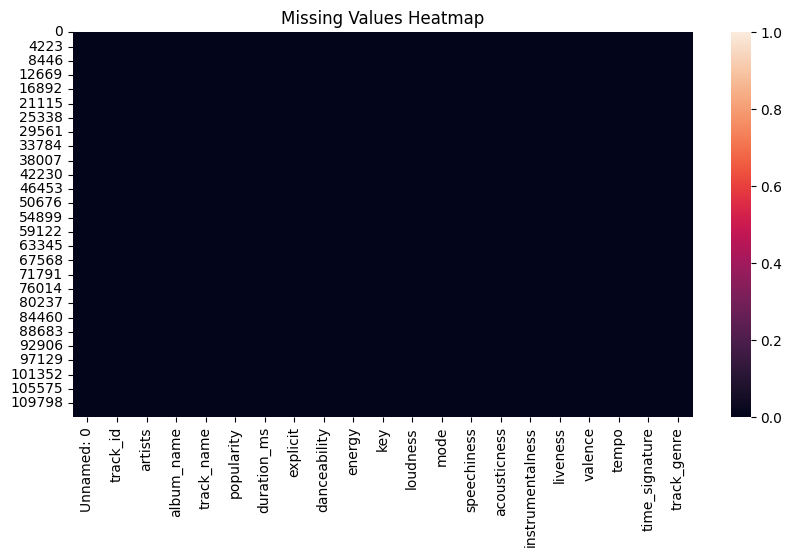

In [6]:
# Visualizing missing values
plt.figure(figsize=(10,5))
sns.heatmap(data.isnull(), cbar=True)
plt.title("Missing Values Heatmap")
plt.show()

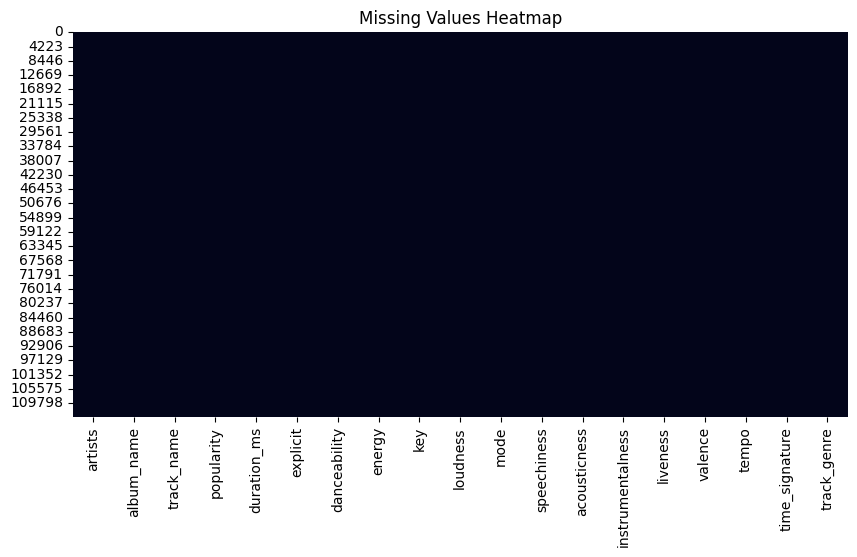

In [7]:
data= data.drop(columns=['Unnamed: 0'])
data=data.drop(columns=['track_id'])
plt.figure(figsize=(10,5))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [8]:
print(data.duplicated().sum()) 

577


In [9]:
data.drop_duplicates(inplace = True)
print(data.duplicated().sum()) 

0


In [10]:
data['energy_dance_ratio'] = data['energy'] / (data['danceability'] + 1e-6) 
data['acoustic_electronic_spectrum'] = data['acousticness'] / (1 - data['acousticness'] + 1e-6)
data['tempo_duration_ratio'] = data['tempo'] / (data['duration_ms'] / 1000) 
data['mood_score'] = (data['valence'] + data['energy']) / 2

In [11]:
data.isna().sum()

artists                         1
album_name                      1
track_name                      1
popularity                      0
duration_ms                     0
explicit                        0
danceability                    0
energy                          0
key                             0
loudness                        0
mode                            0
speechiness                     0
acousticness                    0
instrumentalness                0
liveness                        0
valence                         0
tempo                           0
time_signature                  0
track_genre                     0
energy_dance_ratio              0
acoustic_electronic_spectrum    0
tempo_duration_ratio            0
mood_score                      0
dtype: int64

In [12]:
#normalization using log transformation
data['duration_log'] = np.log1p(data['duration_ms'])
data= data.drop('duration_ms', axis=1)

In [13]:
num_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = data.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical Features:")
print(num_features)
print("Categorical Features:")
print(cat_features)

Numerical Features:
['popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'energy_dance_ratio', 'acoustic_electronic_spectrum', 'tempo_duration_ratio', 'mood_score', 'duration_log']
Categorical Features:
['artists', 'album_name', 'track_name', 'track_genre']


<Axes: >

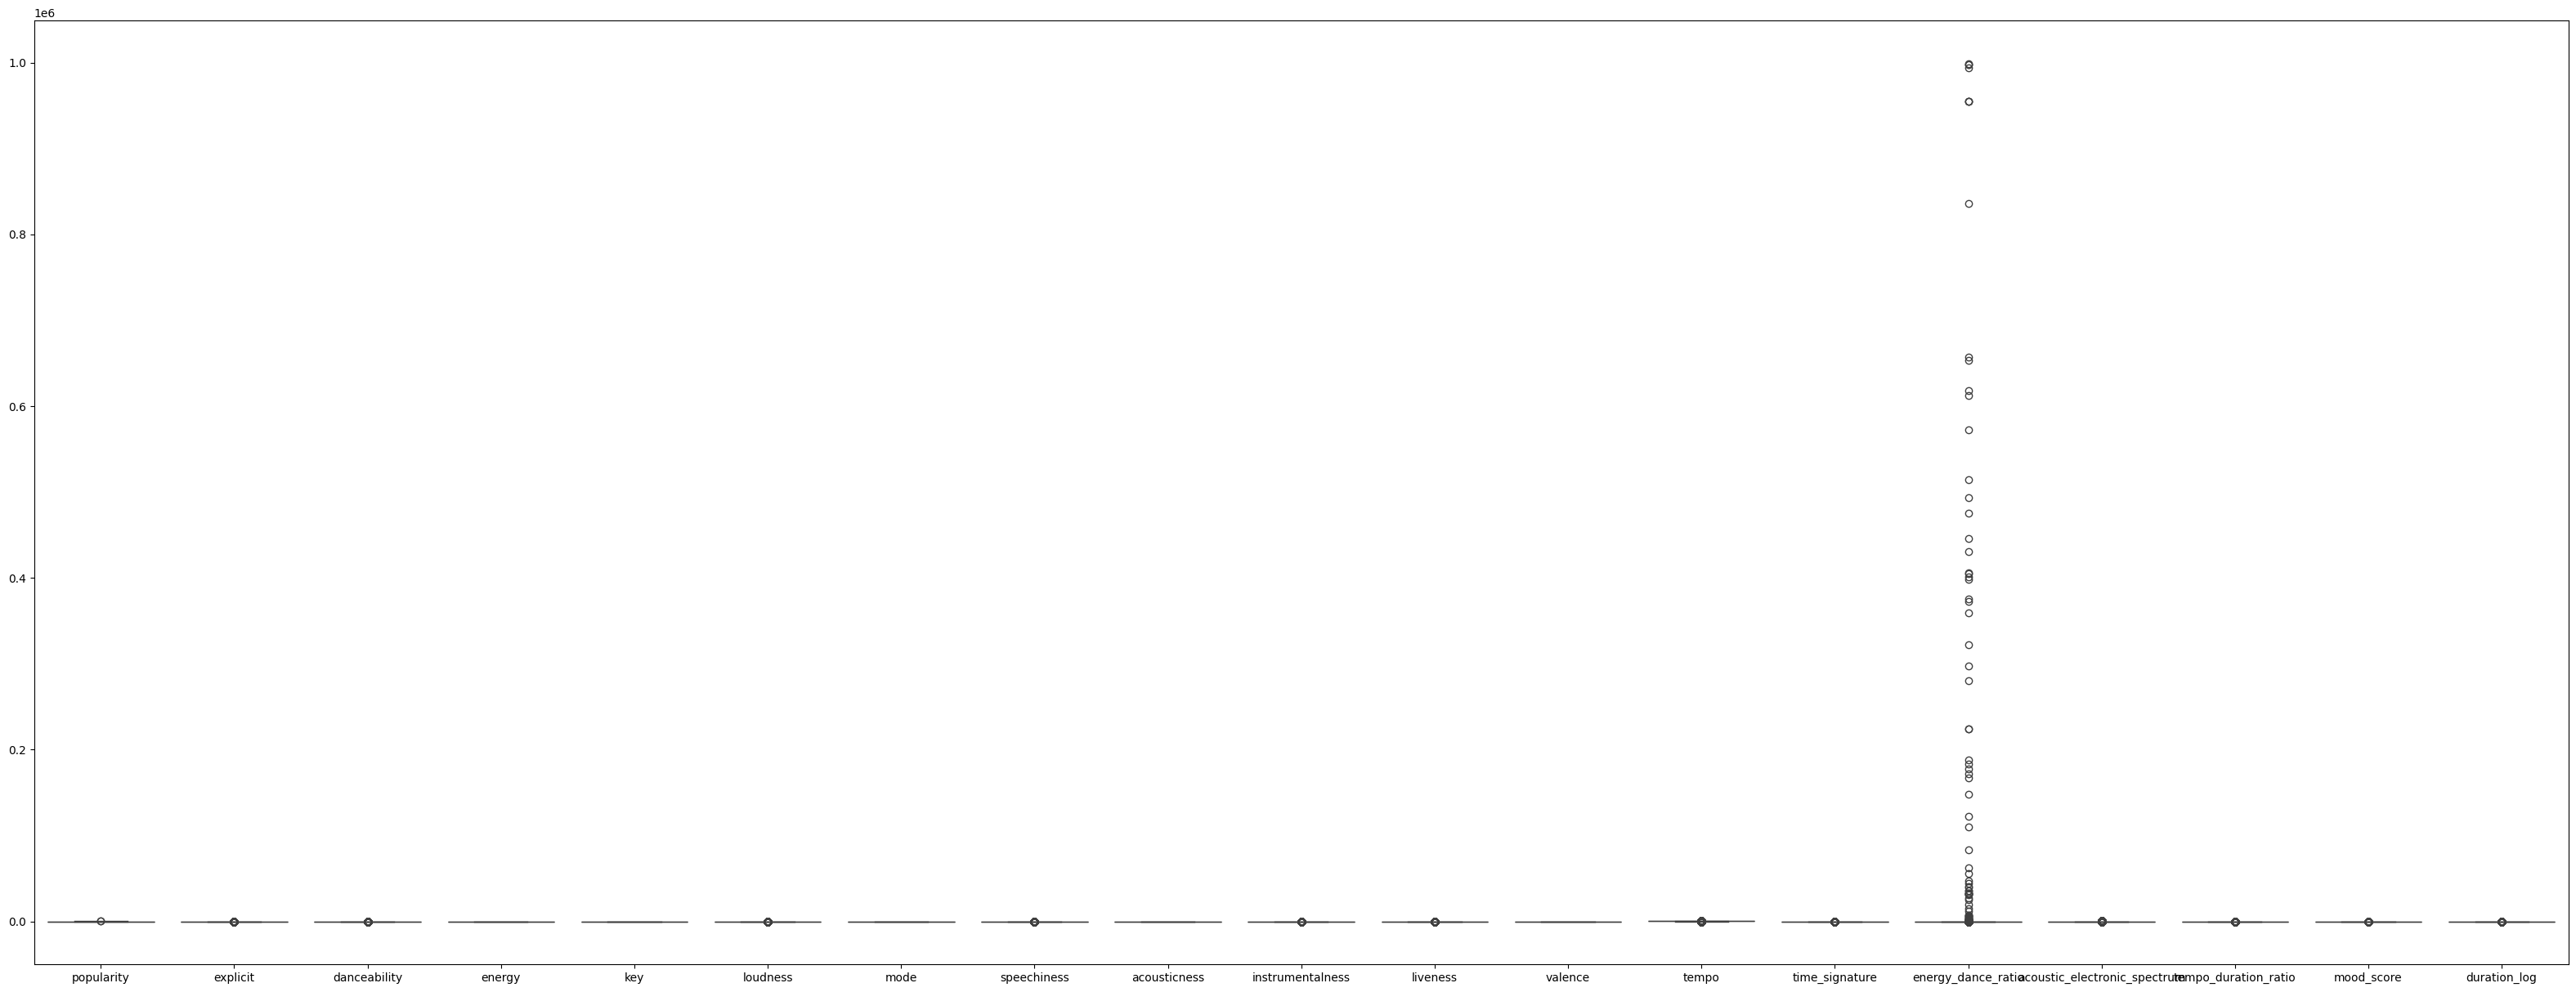

In [14]:
f,ax=plt.subplots(figsize=(40,15))
sns.boxplot(data)

<Axes: >

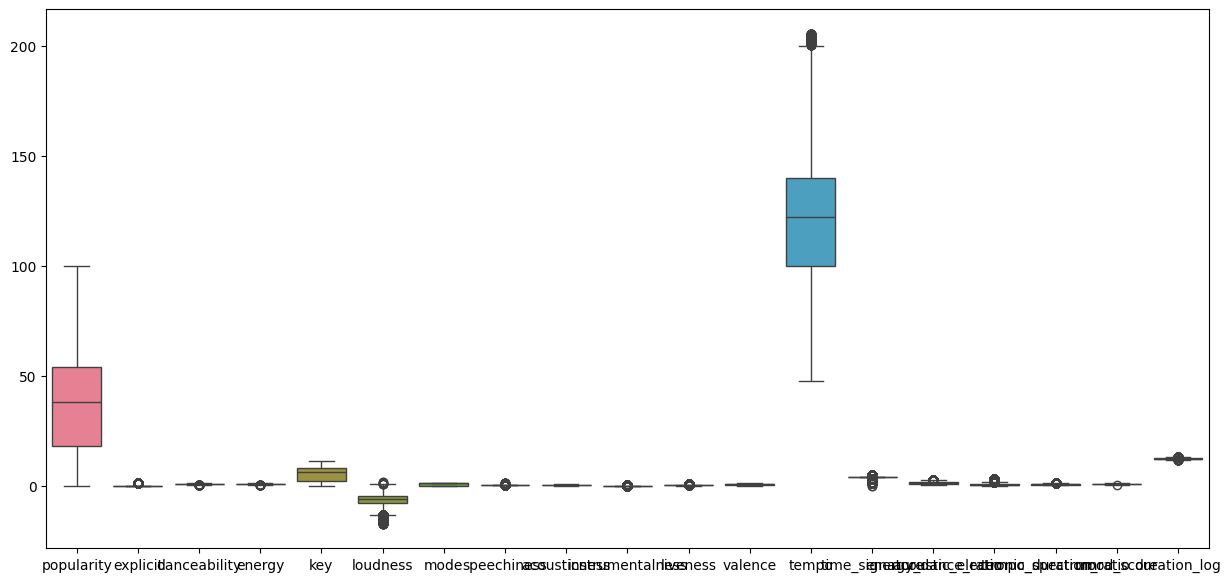

In [15]:

def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers_mask = (data[col] < lower) | (data[col] > upper)
    data = data[~outliers_mask]
    return data
for col in ['danceability', 'loudness', 'instrumentalness', 'liveness',  'tempo', 'energy_dance_ratio', 'acoustic_electronic_spectrum', 'tempo_duration_ratio', 'mood_score', 'duration_log']:
    data = remove_outliers(data, col)
data.reset_index(drop=True, inplace=True)
f,ax=plt.subplots(figsize=(15,7))
sns.boxplot(data)

Text(0.5, 1.0, 'Correlation Heatmap')

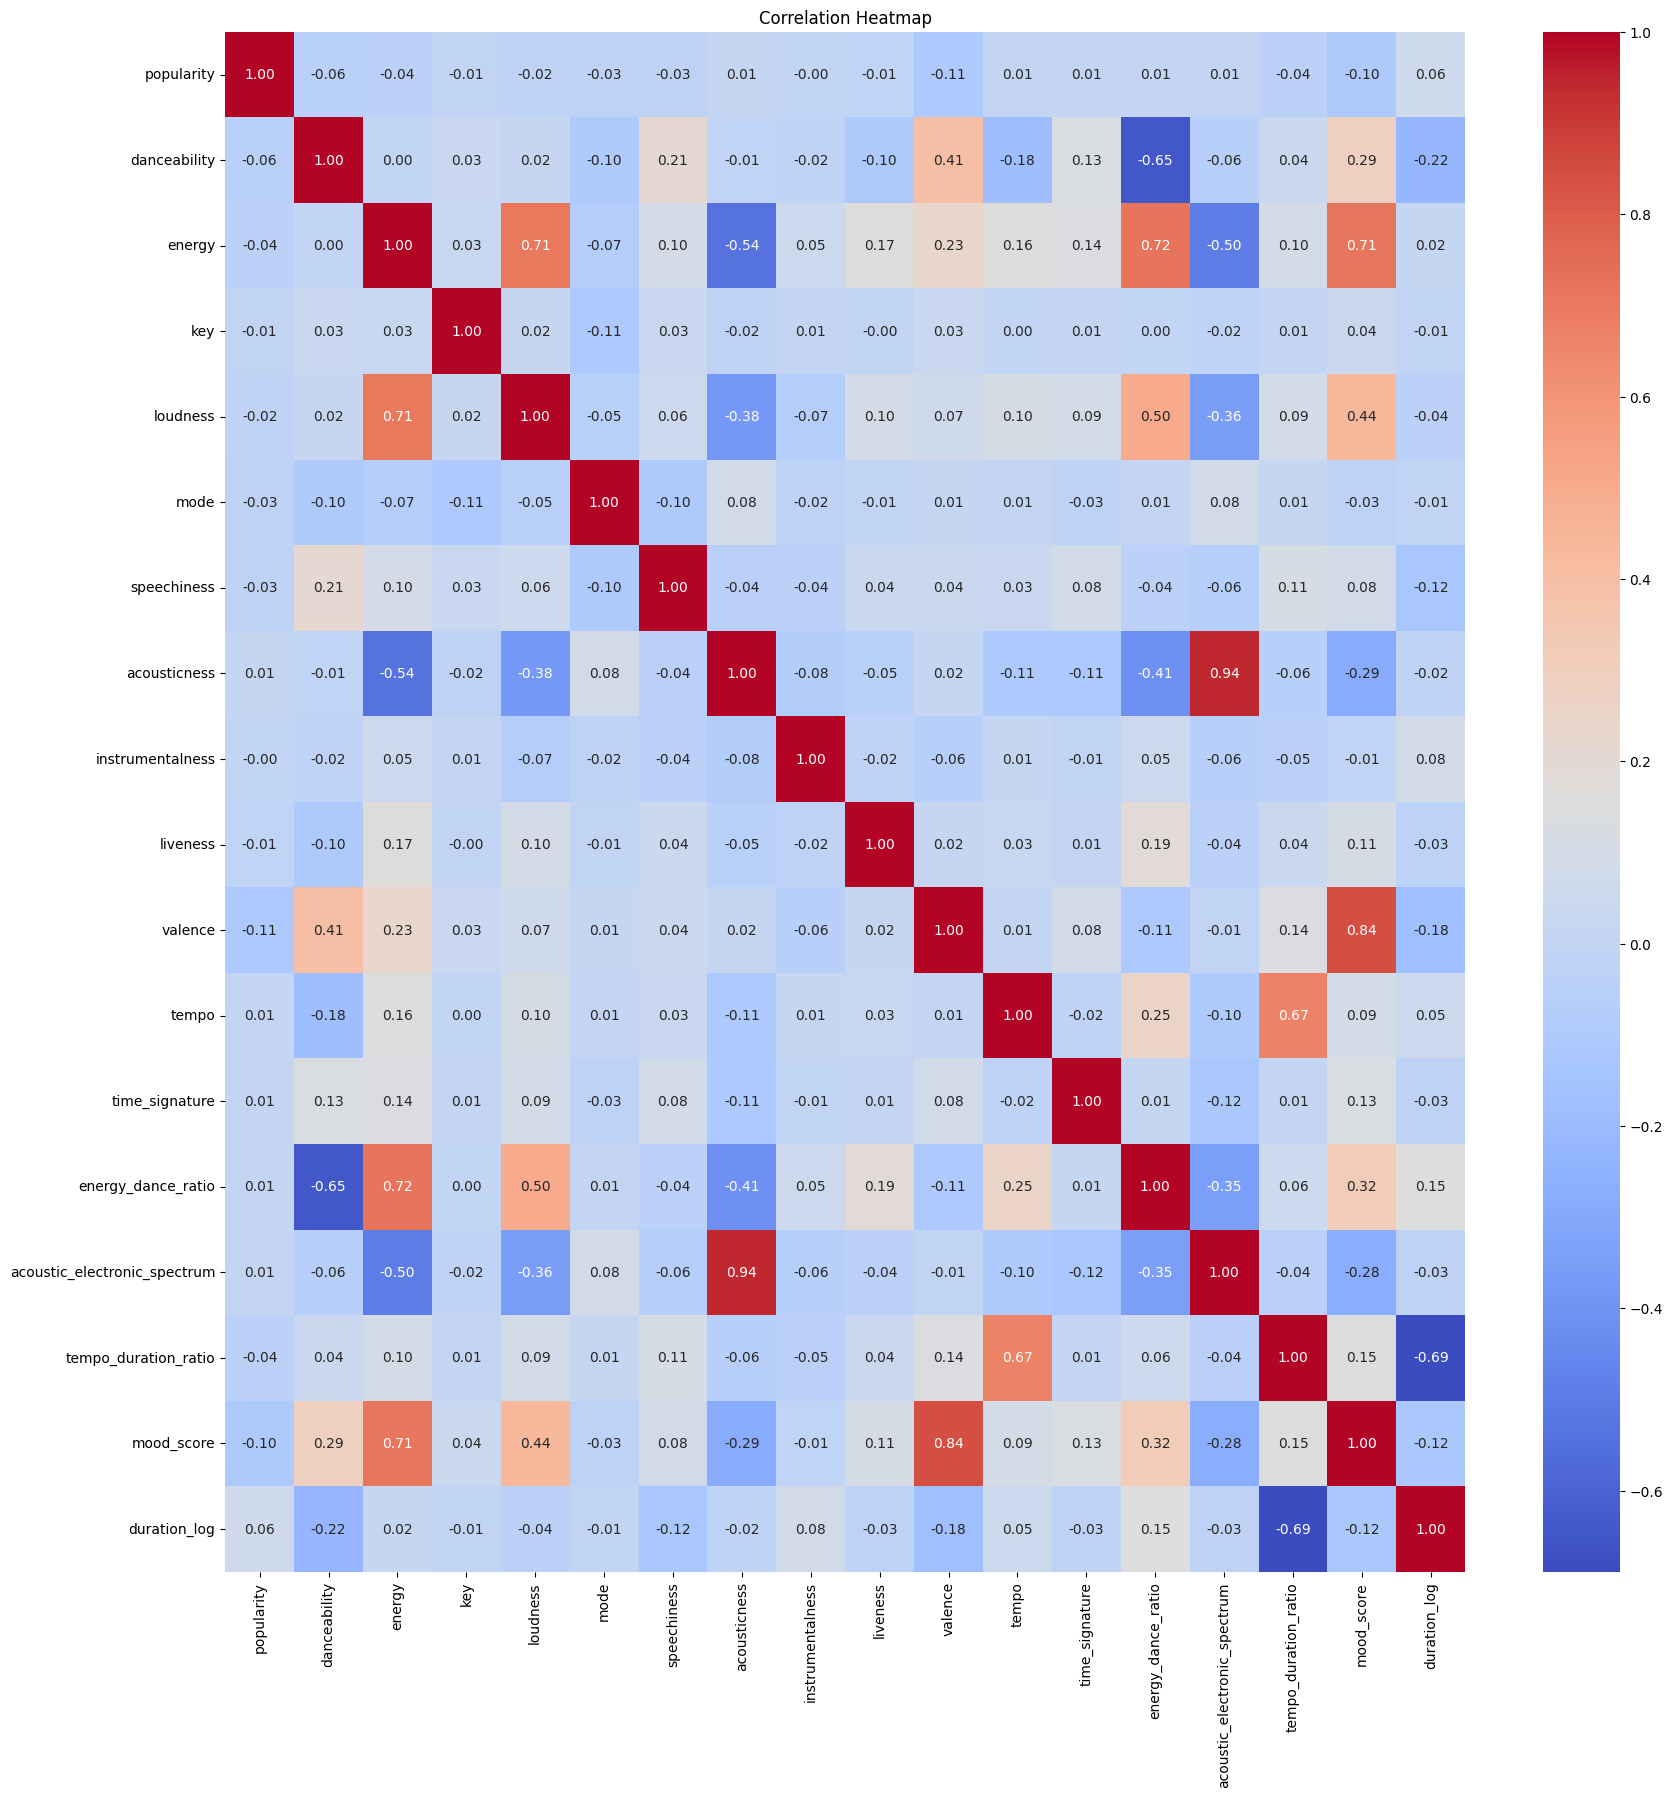

In [16]:
plt.figure(figsize=(20,20))
sns.heatmap(data[num_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")    


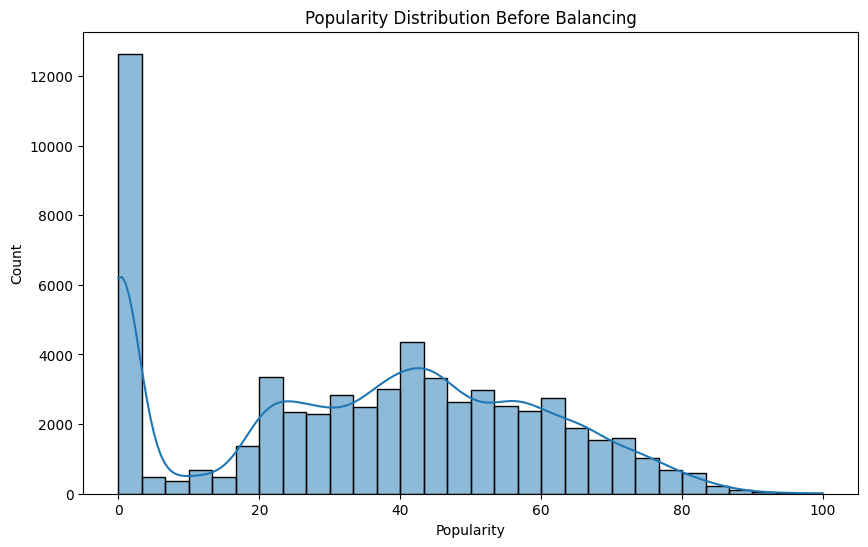

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(data['popularity'], bins=30, kde=True)
plt.title("Popularity Distribution Before Balancing")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()


In [18]:
from sklearn.model_selection import train_test_split
X = data.drop('popularity', axis=1)
y = data['popularity']

num_bins = 10
data['pop_bin'] = pd.cut(y, bins=num_bins, labels=False)

bin_counts = data['pop_bin'].value_counts().sort_index()
weights = data['pop_bin'].apply(lambda x: 1 / bin_counts[x])

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, weights, test_size=0.2, random_state=42)
le = LabelEncoder()
label_encode_features = ['artists', 'track_genre']

# Check if the features exist before attempting to encode
if all(col in X_train.columns for col in label_encode_features):
    for feature in label_encode_features:
        # 1. Convert the column to string type for safety
        X_train_data = X_train[feature].astype(str)
        X_test_data = X_test[feature].astype(str)

        # 2. Fit the encoder ONLY on the training data
        le.fit(X_train_data)

        # 3. Create a map for consistent transformation across train and test sets
        le_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

        # 4. Transform the training data
        X_train[f'{feature}_label_encoded'] = X_train_data.map(le_mapping)

        # 5. Transform the test data safely, filling unseen categories with -1
        X_test[f'{feature}_label_encoded'] = X_test_data.map(le_mapping).fillna(-1).astype(int)

    # --- STEP 3: DROP ORIGINAL COLUMNS ---
    X_train = X_train.drop(columns=label_encode_features, errors='ignore')
    X_test = X_test.drop(columns=label_encode_features, errors='ignore')
    
    print("Label Encoding Complete.")
    print("New columns in X_train:")
    print(X_train.columns.tolist())
else:
    print(f"ERROR: Could not find required columns {label_encode_features} in X_train.")
train_data = X_train.copy()
train_data['popularity'] = y_train


Label Encoding Complete.
New columns in X_train:
['album_name', 'track_name', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'energy_dance_ratio', 'acoustic_electronic_spectrum', 'tempo_duration_ratio', 'mood_score', 'duration_log', 'artists_label_encoded', 'track_genre_label_encoded']


In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48844 entries, 625 to 56422
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   album_name                    48844 non-null  object 
 1   track_name                    48844 non-null  object 
 2   explicit                      48844 non-null  bool   
 3   danceability                  48844 non-null  float64
 4   energy                        48844 non-null  float64
 5   key                           48844 non-null  int64  
 6   loudness                      48844 non-null  float64
 7   mode                          48844 non-null  int64  
 8   speechiness                   48844 non-null  float64
 9   acousticness                  48844 non-null  float64
 10  instrumentalness              48844 non-null  float64
 11  liveness                      48844 non-null  float64
 12  valence                       48844 non-null  float64
 13  temp

In [20]:
X_train.drop(columns=['album_name','track_name'],inplace=True)
X_test.drop(columns=['album_name','track_name'],inplace=True)

In [21]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12211 entries, 2726 to 54099
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   explicit                      12211 non-null  bool   
 1   danceability                  12211 non-null  float64
 2   energy                        12211 non-null  float64
 3   key                           12211 non-null  int64  
 4   loudness                      12211 non-null  float64
 5   mode                          12211 non-null  int64  
 6   speechiness                   12211 non-null  float64
 7   acousticness                  12211 non-null  float64
 8   instrumentalness              12211 non-null  float64
 9   liveness                      12211 non-null  float64
 10  valence                       12211 non-null  float64
 11  tempo                         12211 non-null  float64
 12  time_signature                12211 non-null  int64  
 13  ene

In [22]:
X_train.head()

,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,energy_dance_ratio,acoustic_electronic_spectrum,tempo_duration_ratio,mood_score,duration_log,artists_label_encoded,track_genre_label_encoded
625,False,0.778,0.243,9,-15.168,1,0.0596,0.640,0.002040,0.0823,0.714,166.027,3,0.312339,1.777773,0.944054,0.4785,12.077483,7167,1
46429,True,0.740,0.655,7,-7.140,0,0.0350,0.323,0.000068,0.1110,0.964,107.009,4,0.885134,0.477104,0.370189,0.8095,12.574414,10978,85
16586,True,0.498,0.739,10,-5.881,1,0.1280,0.464,0.000000,0.1300,0.302,82.509,4,1.483933,0.865670,0.472698,0.5205,12.069967,4575,33
26506,False,0.546,0.360,10,-9.531,1,0.0269,0.666,0.000005,0.3830,0.364,103.434,3,0.659339,1.994006,0.632601,0.3620,12.004611,5529,52
40310,False,0.583,0.782,7,-6.748,0,0.0291,0.001,0.039700,0.3250,0.307,98.022,4,1.341336,0.001001,0.362490,0.5445,12.507709,3001,75


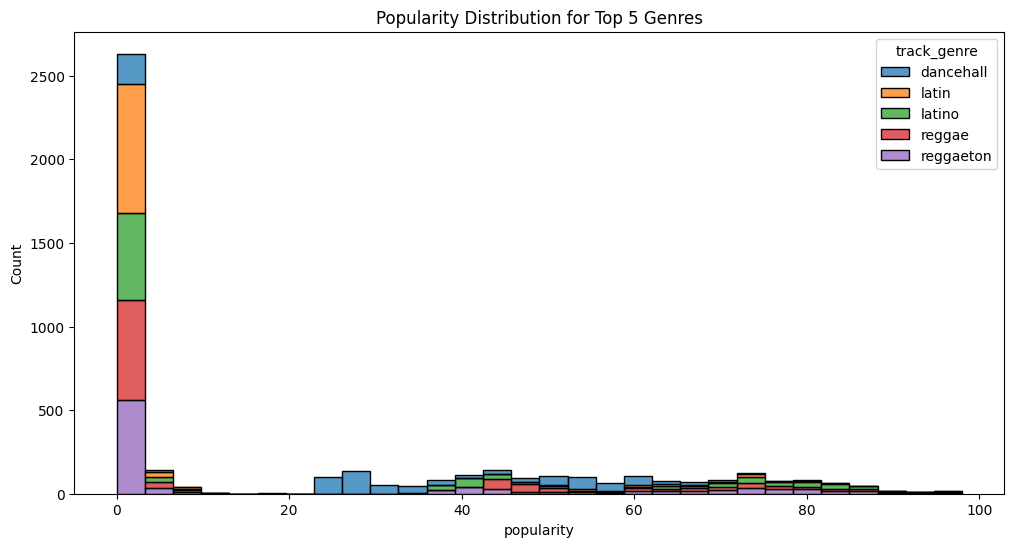

In [23]:
#EDA
top_genres = data['track_genre'].value_counts().nlargest(5).index  #TAKING TOP 5 GENRES to make the plot less cluttered
subset = data[data['track_genre'].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.histplot(data=subset, x='popularity', hue='track_genre', multiple='stack', bins=30, kde=False)
plt.title("Popularity Distribution for Top 5 Genres")
plt.show()


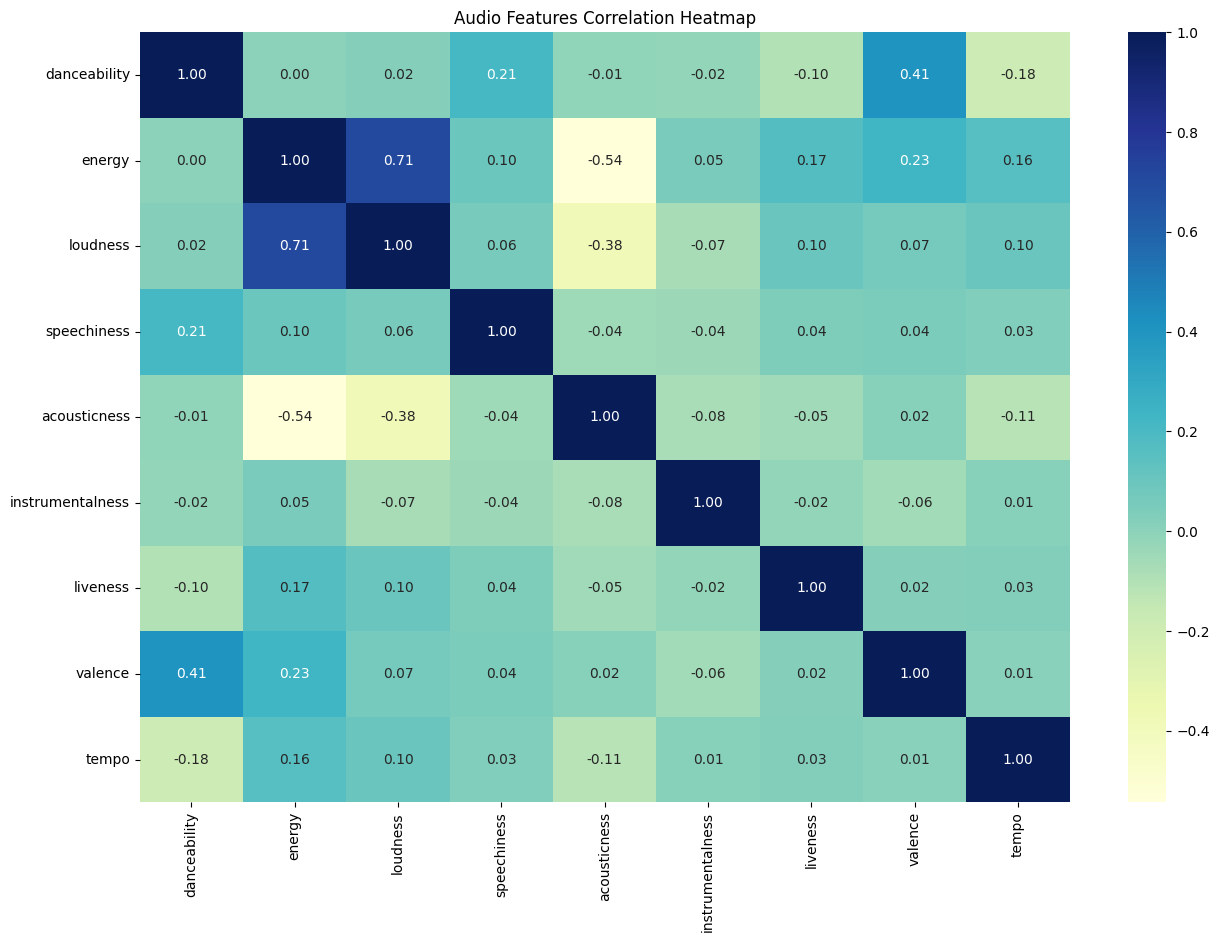

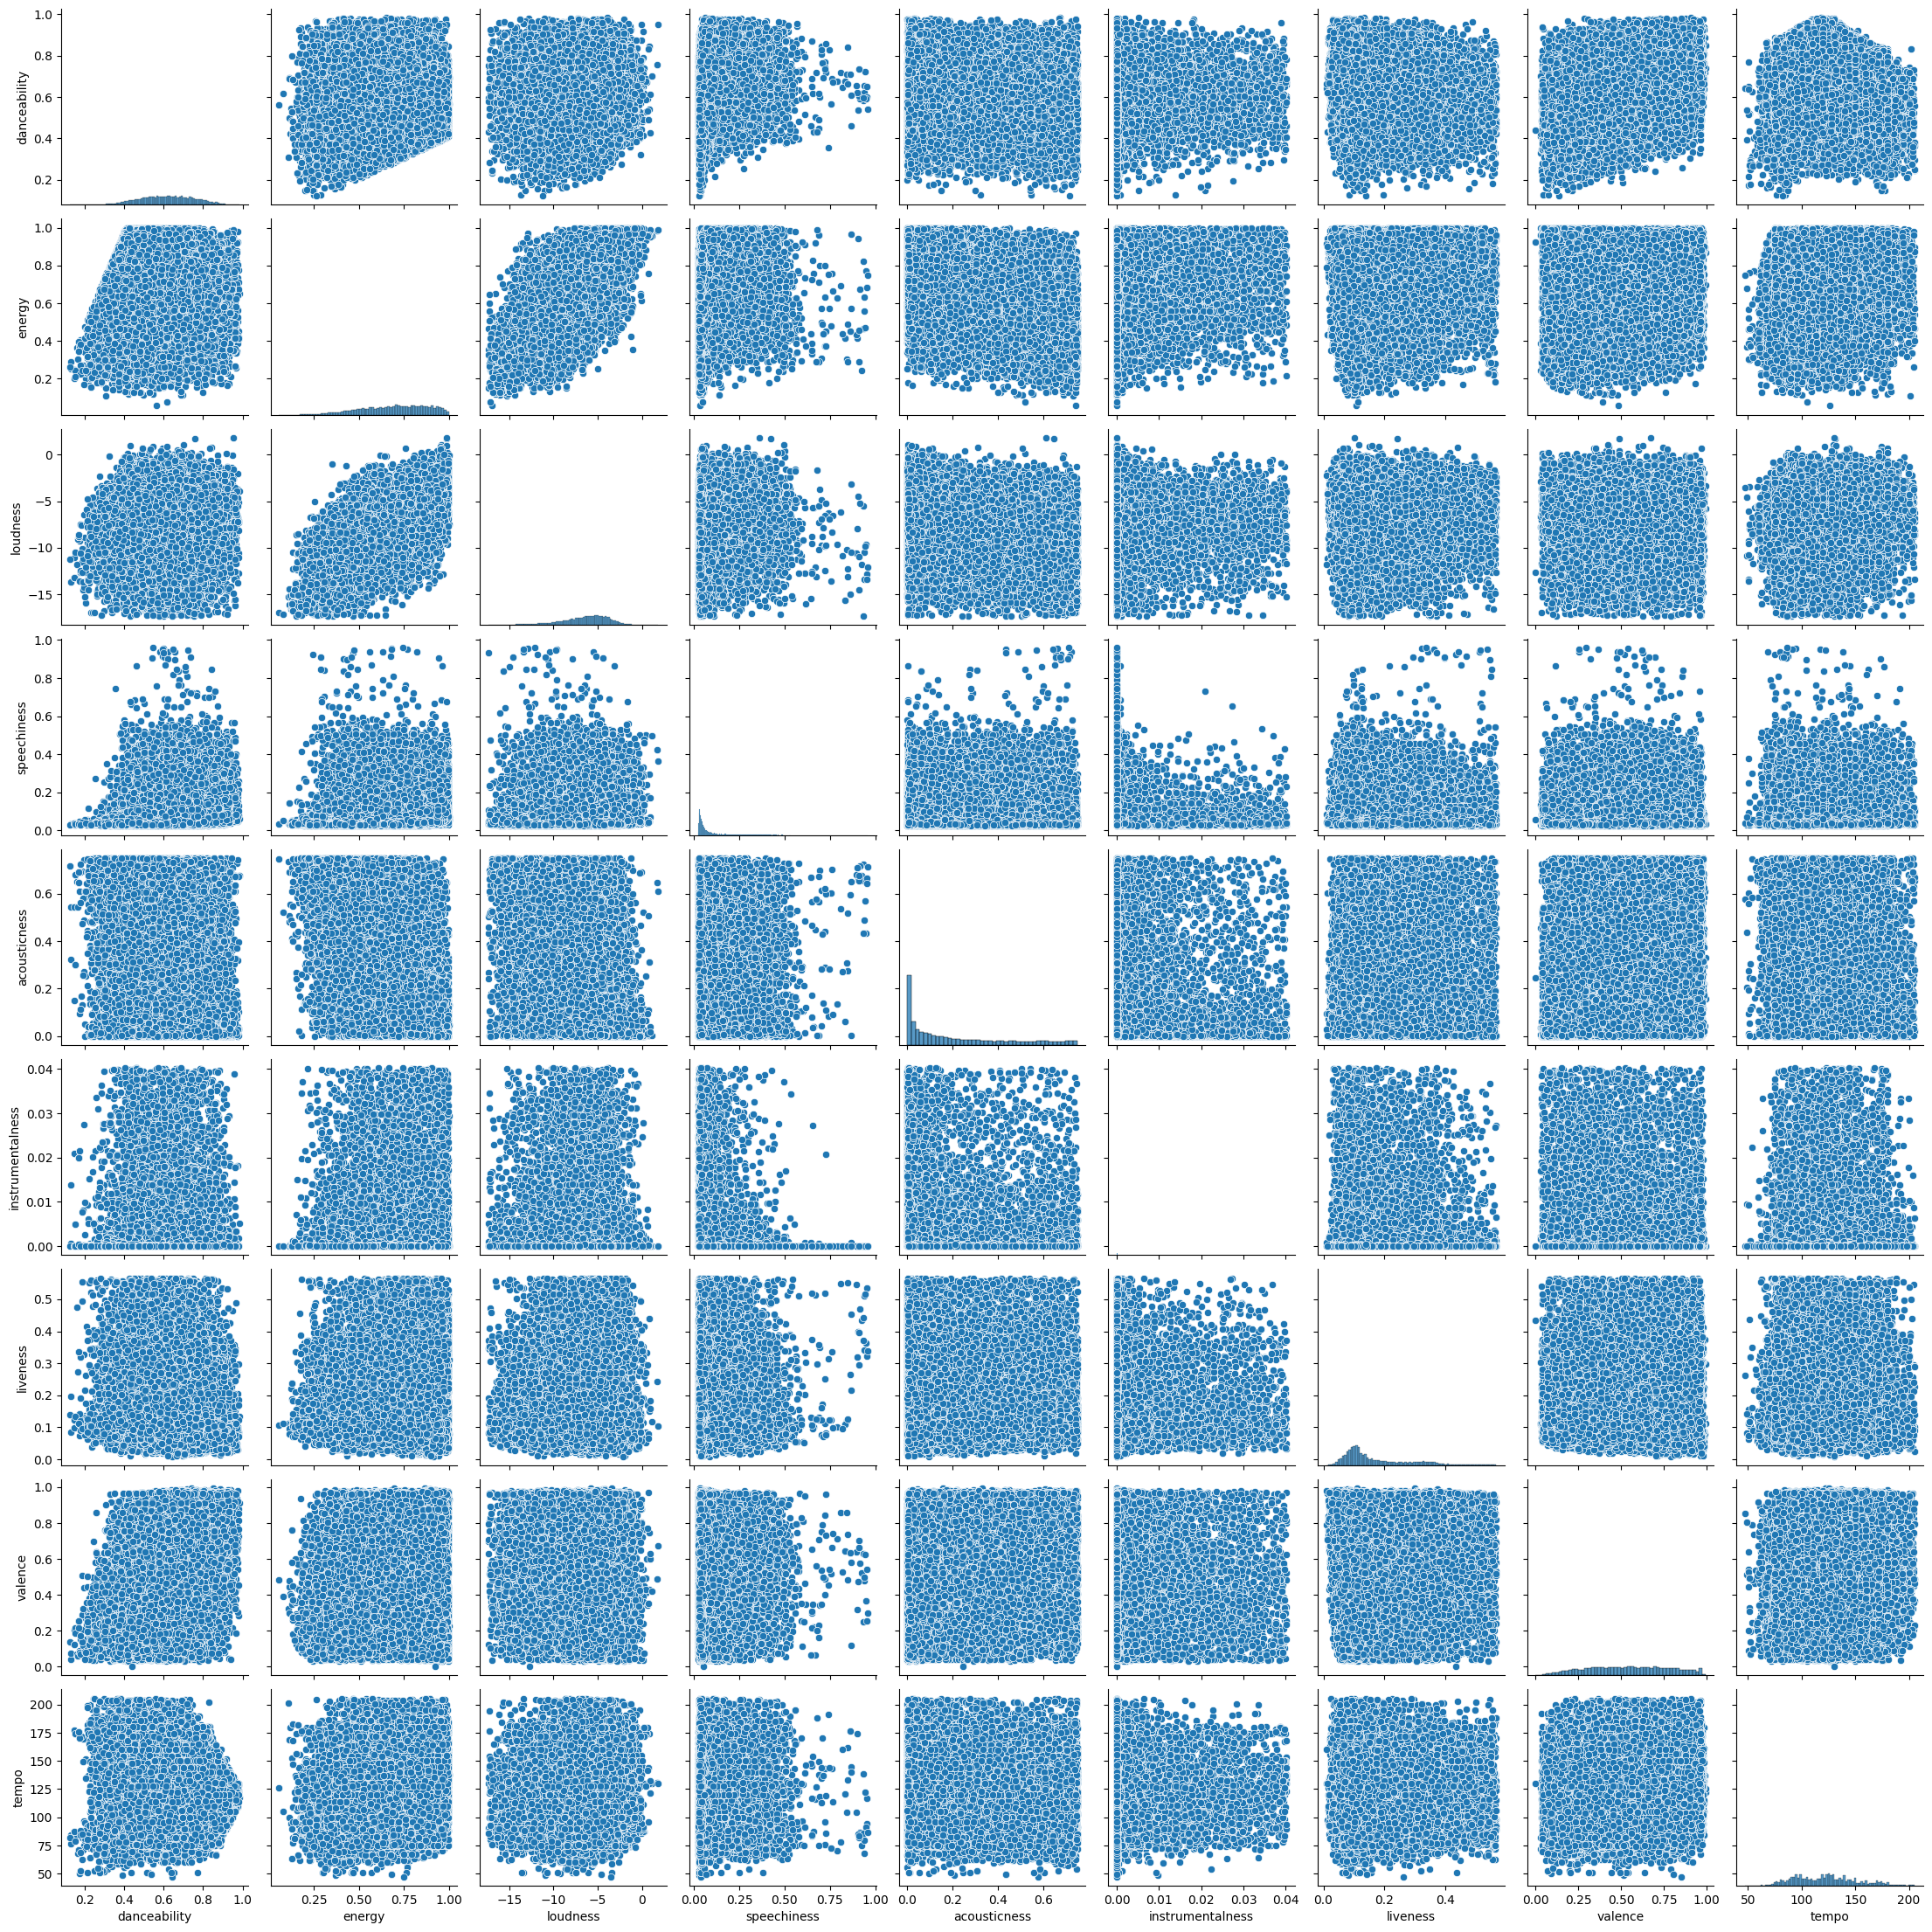

In [24]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
plt.figure(figsize=(15,10))
sns.heatmap(data[audio_features].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Audio Features Correlation Heatmap")
sns.pairplot(data[audio_features])

<Figure size 1500x1000 with 0 Axes>

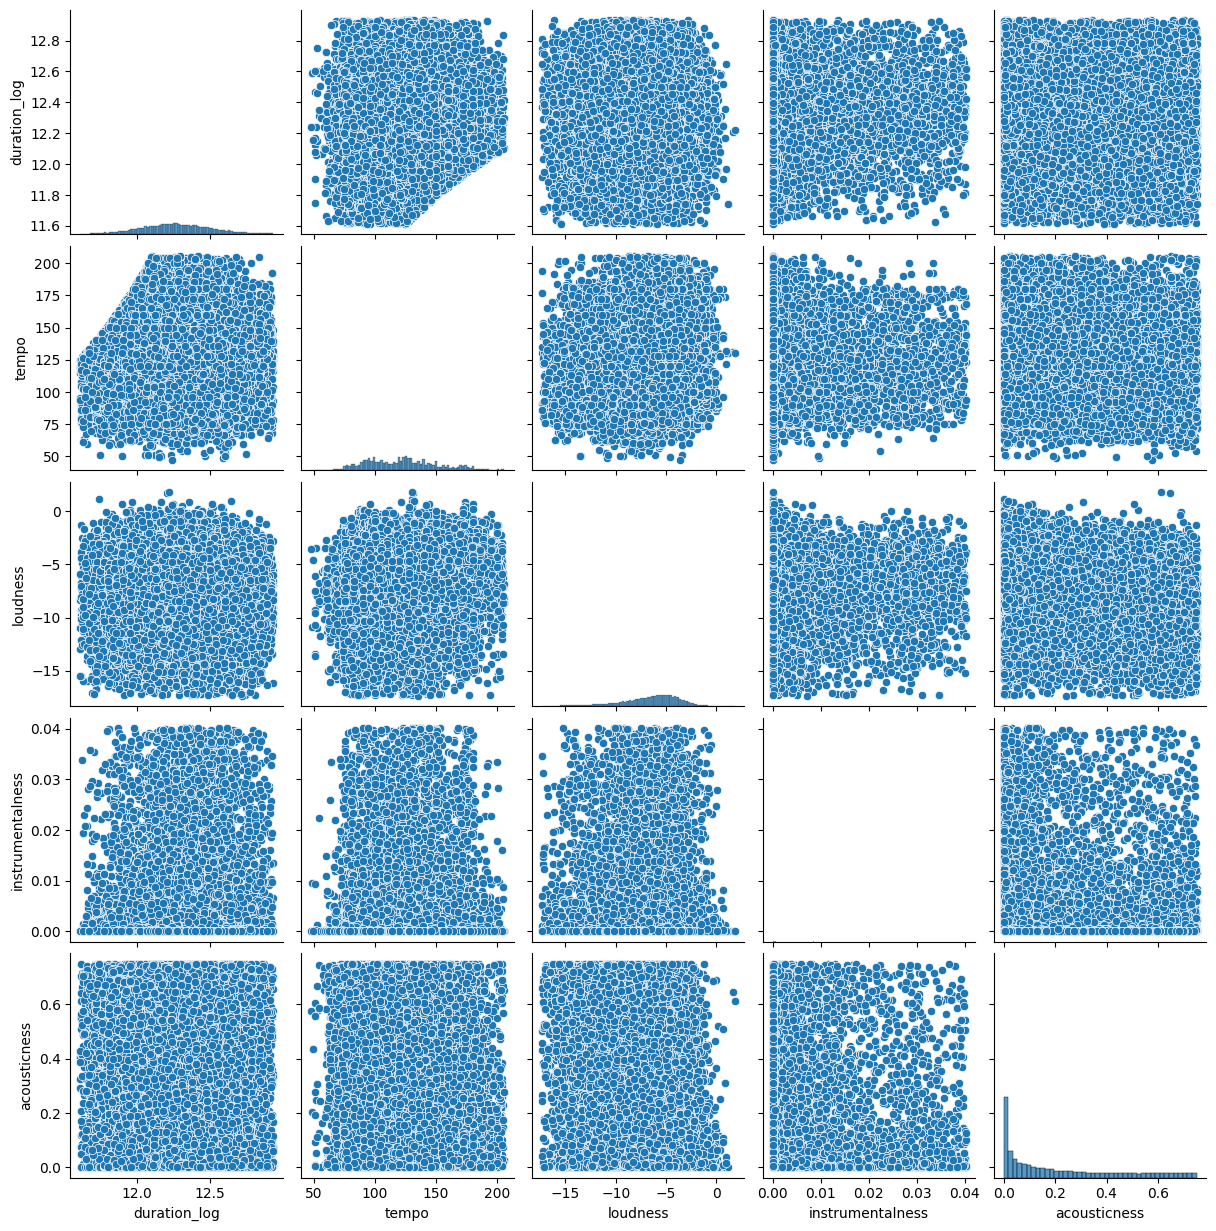

In [25]:
temporal_features = ['duration_log', 'tempo','loudness','instrumentalness','acousticness']
plt.figure(figsize=(15,10))
sns.pairplot(data[temporal_features])


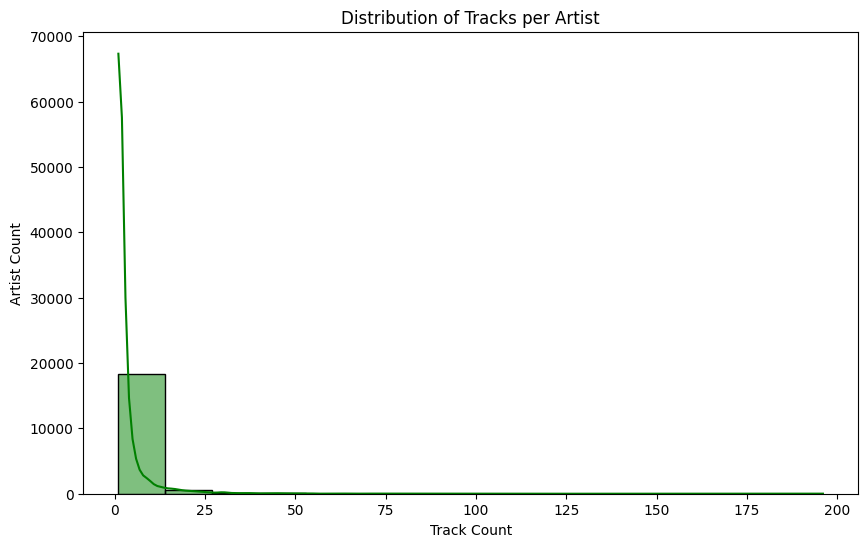

In [26]:
track_counts = data.groupby('artists')['track_name'].count().reset_index()
track_counts.rename(columns={'track_name': 'track_count'}, inplace=True)
plt.figure(figsize=(10, 6))
sns.histplot(track_counts['track_count'], bins=15, kde=True, color='green')
plt.title('Distribution of Tracks per Artist')
plt.xlabel('Track Count')
plt.ylabel('Artist Count')
plt.show()

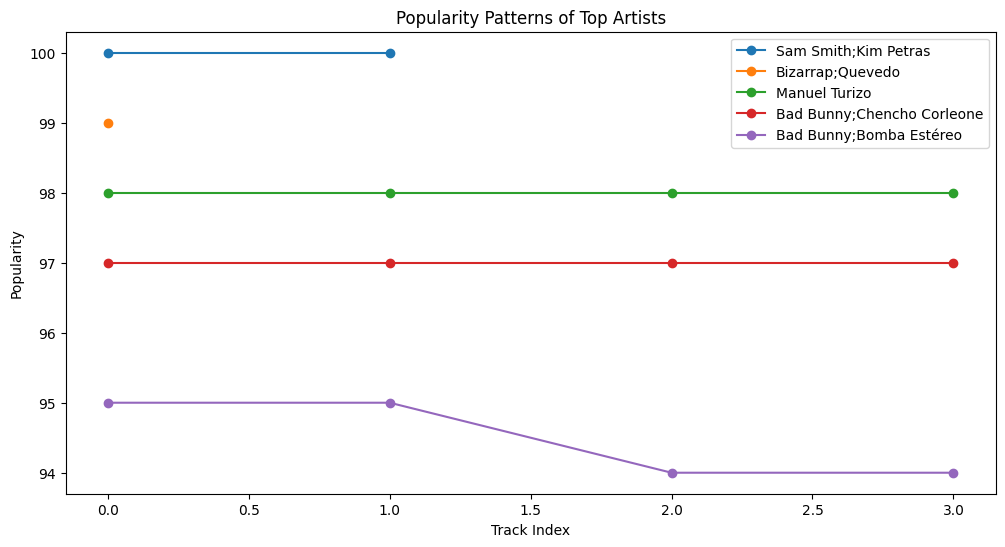

In [27]:
top_artists = data.groupby('artists')['popularity'].mean().nlargest(5).index
plt.figure(figsize=(12,6))
for artist in top_artists:
    artist_tracks = data[data['artists']==artist]
    plt.plot(range(len(artist_tracks)), artist_tracks['popularity'].values, marker='o', label=artist)
plt.xlabel("Track Index")
plt.ylabel("Popularity")
plt.title("Popularity Patterns of Top Artists")
plt.legend()
plt.show()


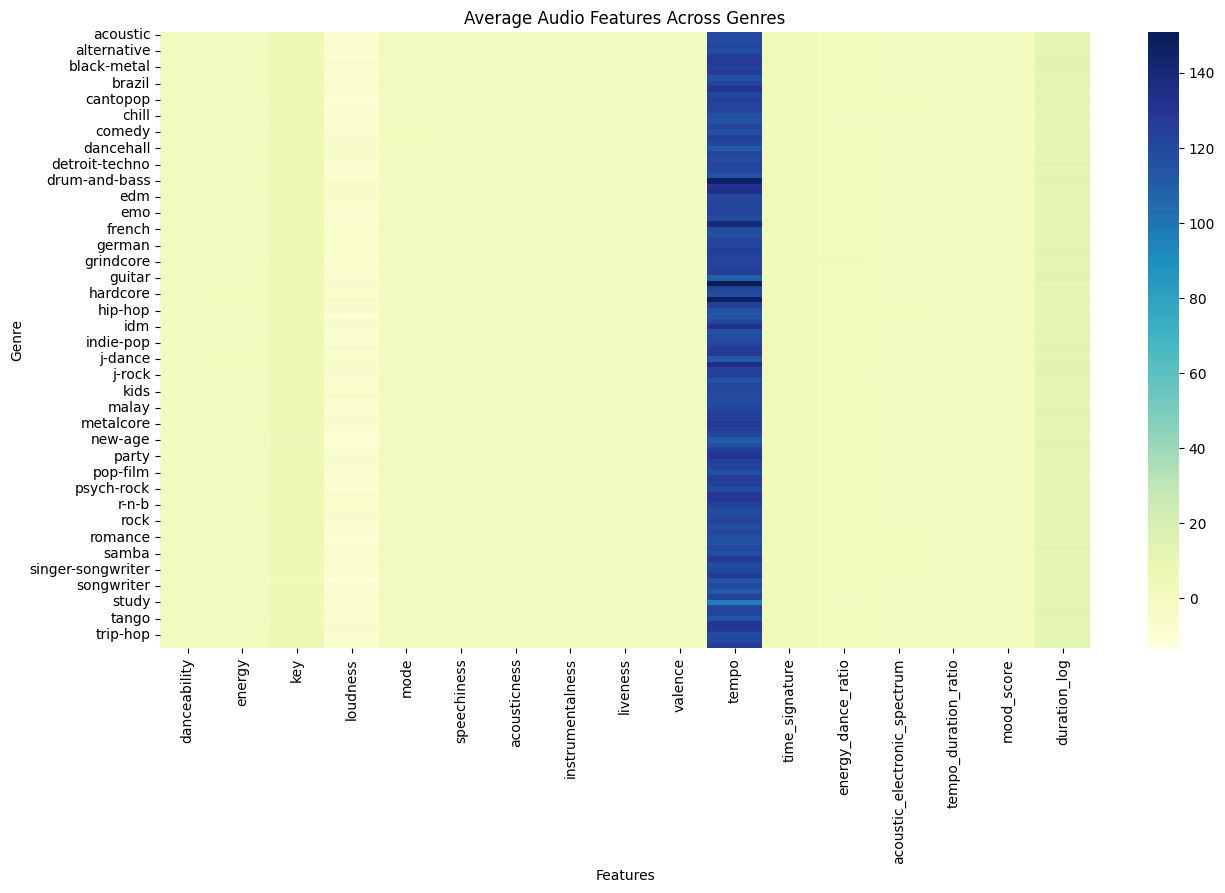

In [28]:
genre_features = data.groupby('track_genre')[num_features].mean()
plt.figure(figsize=(15,8))
sns.heatmap(genre_features.drop(columns='popularity'), cmap="YlGnBu")
plt.title("Average Audio Features Across Genres")
plt.xlabel("Features")
plt.ylabel("Genre")
plt.show()

# Supervised ML 

In [29]:
from sklearn.model_selection import train_test_split
X = data.drop('popularity', axis=1)
y = data['popularity']

num_bins = 10
data['pop_bin'] = pd.cut(y, bins=num_bins, labels=False)

bin_counts = data['pop_bin'].value_counts().sort_index()
weights = data['pop_bin'].apply(lambda x: 1 / bin_counts[x])

split_idx = int(len(X) * 0.8)
X_train2, X_test2 = X.iloc[:split_idx], X.iloc[split_idx:]
y_train2, y_test2 = y.iloc[:split_idx], y.iloc[split_idx:]
w_train2, w_test2 = weights.iloc[:split_idx], weights.iloc[split_idx:]

le = LabelEncoder()
label_encode_features = ['artists', 'track_genre']

# Check if the features exist before attempting to encode
if all(col in X_train2.columns for col in label_encode_features):
    for feature in label_encode_features:
        # 1. Convert the column to string type for safety
        X_train_data = X_train2[feature].astype(str)
        X_test_data = X_test2[feature].astype(str)

        # 2. Fit the encoder ONLY on the training data
        le.fit(X_train_data)

        # 3. Create a map for consistent transformation across train and test sets
        le_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

        # 4. Transform the training data
        X_train2[f'{feature}_label_encoded'] = X_train_data.map(le_mapping)

        # 5. Transform the test data safely, filling unseen categories with -1
        X_test2[f'{feature}_label_encoded'] = X_test_data.map(le_mapping).fillna(-1).astype(int)

    # --- STEP 3: DROP ORIGINAL COLUMNS ---
    X_train2 = X_train2.drop(columns=label_encode_features, errors='ignore')
    X_test2 = X_test2.drop(columns=label_encode_features, errors='ignore')
    
    print("Label Encoding Complete.")
    print("New columns in X_train2:")
    print(X_train2.columns.tolist())
else:
    print(f"ERROR: Could not find required columns {label_encode_features} in X_train2.")
train_data = X_train2.copy()
train_data['popularity'] = y_train2


Label Encoding Complete.
New columns in X_train2:
['album_name', 'track_name', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'energy_dance_ratio', 'acoustic_electronic_spectrum', 'tempo_duration_ratio', 'mood_score', 'duration_log', 'pop_bin', 'artists_label_encoded', 'track_genre_label_encoded']


In [30]:
X_train2.drop(columns=['album_name','track_name'],inplace=True)
X_test2.drop(columns=['album_name','track_name'],inplace=True)

In [31]:
X_train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48844 entries, 0 to 48843
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   explicit                      48844 non-null  bool   
 1   danceability                  48844 non-null  float64
 2   energy                        48844 non-null  float64
 3   key                           48844 non-null  int64  
 4   loudness                      48844 non-null  float64
 5   mode                          48844 non-null  int64  
 6   speechiness                   48844 non-null  float64
 7   acousticness                  48844 non-null  float64
 8   instrumentalness              48844 non-null  float64
 9   liveness                      48844 non-null  float64
 10  valence                       48844 non-null  float64
 11  tempo                         48844 non-null  float64
 12  time_signature                48844 non-null  int64  
 13  e

In [32]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np


tscv = TimeSeriesSplit(n_splits=5)

def xgb_evaluate(max_depth, learning_rate, subsample, colsample_bytree, n_estimators):
  

    
    params = {
        "objective": "reg:squarederror",
        "max_depth": int(max_depth),
        "learning_rate": learning_rate,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "n_estimators": int(n_estimators),
        "random_state": 42,
    }
    
    model = XGBRegressor(**params)
    rmses = []

    
    for train_idx, val_idx in tscv.split(X_train2):
        X_tr, X_val = X_train2.iloc[train_idx], X_train2.iloc[val_idx]
        y_tr, y_val = y_train2.iloc[train_idx], y_train2.iloc[val_idx]
        w_tr, w_val = w_train2.iloc[train_idx], w_train2.iloc[val_idx]

        
        model.fit(X_tr, y_tr, sample_weight=w_tr)

        
        preds = model.predict(X_val)

        
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        rmses.append(rmse)

    
    return -np.mean(rmses)


In [33]:
from bayes_opt import BayesianOptimization


bounds = {
    "max_depth": (3, 10),
    "learning_rate": (0.01, 0.2),
    "subsample": (0.8, 1.0),
    "colsample_bytree": (0.8, 1.0),
    "n_estimators": (100, 400),
}


optimizer = BayesianOptimization(
    f=xgb_evaluate,   
    pbounds=bounds,
    random_state=42,
    verbose=2
)


optimizer.maximize(
    init_points=5,    
    n_iter=25         
)


print("Best hyperparameters found:")
print(optimizer.max)


|   iter    |  target   | max_depth | learni... | subsample | colsam... | n_esti... |
-------------------------------------------------------------------------------------
| 1         | -12.64688 | 5.6217808 | 0.1906357 | 0.9463987 | 0.9197316 | 146.80559 |
| 2         | -12.27487 | 4.0919616 | 0.0210358 | 0.9732352 | 0.9202230 | 312.42177 |
| 3         | -12.17682 | 3.1440914 | 0.1942828 | 0.9664885 | 0.8424678 | 154.54749 |
| 4         | -12.70746 | 4.2838315 | 0.0678060 | 0.9049512 | 0.8863890 | 187.36874 |
| 5         | -13.32044 | 7.2829702 | 0.0365038 | 0.8584289 | 0.8732723 | 236.82099 |
| 6         | -14.81034 | 7.2528139 | 0.0110144 | 0.9570890 | 0.9263280 | 235.21714 |
| 7         | -12.19097 | 3.4697306 | 0.1527690 | 0.9731361 | 0.9683809 | 153.23117 |
| 8         | -12.20372 | 5.2437695 | 0.1609529 | 0.9734405 | 0.8381408 | 154.39666 |
| 9         | -17.46562 | 4.5559451 | 0.01      | 0.8       | 1.0       | 157.02070 |
| 10        | -13.23700 | 5.2488482 | 0.2       | 0.8 

In [34]:
best_params = optimizer.max['params']
best_params['max_depth'] = int(best_params['max_depth'])
best_params['n_estimators'] = int(best_params['n_estimators'])
print("Best hyperparameters:", best_params)


Best hyperparameters: {'max_depth': 8, 'learning_rate': 0.11859177763043646, 'subsample': 0.9998327766276902, 'colsample_bytree': 0.8700042689331763, 'n_estimators': 251}


In [35]:
final_model = XGBRegressor(**best_params, objective='reg:squarederror', random_state=42)
final_model.fit(X_train2, y_train2, sample_weight=w_train2)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8700042689331763, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.11859177763043646,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=251, n_jobs=None,
             num_parallel_tree=None, ...)

In [36]:


preds_test = final_model.predict(X_test2)
rmse_test = np.sqrt(mean_squared_error(y_test2, preds_test))
r2_test = r2_score(y_test2, preds_test)

print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test R²: {r2_test:.4f}")


Test RMSE: 5.1870
Test R²: 0.9451


### Random Forest

In [37]:
rf_model = RandomForestRegressor(
    n_estimators=200,       
    max_depth=None,         
    random_state=42,
                  
)

In [38]:
rf_model.fit(,y_train2,sample_weight=w_train2)

RandomForestRegressor(n_estimators=200, random_state=42)

In [39]:
rf_pred=rf_model.predict(X_test2)

In [67]:
X_test2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12211 entries, 48844 to 61054
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   explicit                      12211 non-null  float64
 1   danceability                  12211 non-null  float64
 2   energy                        12211 non-null  float64
 3   key                           12211 non-null  float64
 4   loudness                      12211 non-null  float64
 5   mode                          12211 non-null  float64
 6   speechiness                   12211 non-null  float64
 7   acousticness                  12211 non-null  float64
 8   instrumentalness              12211 non-null  float64
 9   liveness                      12211 non-null  float64
 10  valence                       12211 non-null  float64
 11  tempo                         12211 non-null  float64
 12  time_signature                12211 non-null  float64
 1

In [40]:

print(f"Random Forest Test RMSE: {root_mean_squared_error(y_test2, rf_pred)}")
print(f"Random Forest Test R²: {r2_score(y_test2, rf_pred)}")

Random Forest Test RMSE: 2.5608263240626465
Random Forest Test R²: 0.9866067078803857


## Neural Network

In [41]:

X_train2 = X_train2.astype(float)
X_test2 = X_test2.astype(float)


y_train2 = y_train2.astype(float)
y_test2 = y_test2.astype(float)
w_train2 = w_train2.astype(float)
w_test2 = w_test2.astype(float)




In [42]:
n_features = X_train2.shape[1]

model = Sequential([
    Dense(512, activation='relu', input_shape=(n_features,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError()])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │          11,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,809 (718.00 KB)

 Trainable params: 183,809 (718.00 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = model.fit(
    X_train2.values,
    y_train2.values,
    sample_weight=w_train2.values,
    validation_split=0.1,
    epochs=20,
    batch_size=256,
    verbose=2
)


Epoch 1/20
172/172 - 3s - 15ms/step - loss: 1.5602 - root_mean_squared_error: 99.3354 - val_loss: 0.4093 - val_root_mean_squared_error: 62.7678
Epoch 2/20
172/172 - 1s - 6ms/step - loss: 0.2040 - root_mean_squared_error: 34.5247 - val_loss: 0.1535 - val_root_mean_squared_error: 32.4803
Epoch 3/20
172/172 - 1s - 6ms/step - loss: 0.1529 - root_mean_squared_error: 29.6299 - val_loss: 0.1378 - val_root_mean_squared_error: 30.3125
Epoch 4/20
172/172 - 1s - 7ms/step - loss: 0.1655 - root_mean_squared_error: 31.0074 - val_loss: 0.1211 - val_root_mean_squared_error: 26.6239
Epoch 5/20
172/172 - 1s - 7ms/step - loss: 0.1643 - root_mean_squared_error: 30.6807 - val_loss: 0.1217 - val_root_mean_squared_error: 26.7300
Epoch 6/20
172/172 - 1s - 6ms/step - loss: 0.1243 - root_mean_squared_error: 27.0402 - val_loss: 0.1756 - val_root_mean_squared_error: 22.7886
Epoch 7/20
172/172 - 1s - 6ms/step - loss: 0.1278 - root_mean_squared_error: 27.4326 - val_loss: 0.1972 - val_root_mean_squared_error: 24.274

## Evaluate using business-relevant metrics beyond RMSE 

In [44]:
preds = model.predict(X_test2.values)


rmse = np.sqrt(mean_squared_error(y_test2, preds))
r2 = r2_score(y_test2, preds)

print(f"Neural Network Test RMSE: {rmse:.4f}")
print(f"Neural Network Test R²: {r2:.4f}")


382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Neural Network Test RMSE: 4.0926
Neural Network Test R²: 0.9658


In [45]:
corr, _ = spearmanr(y_test2.values, preds.flatten())
print(f"Spearman Rank Correlation: {corr:.4f}")


Spearman Rank Correlation: 0.9740


In [46]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [47]:
num_bins = 10
bins = np.linspace(y.min(), y.max(), num_bins + 1)

pred_bins = np.digitize(preds.flatten(), bins=bins) - 1
true_bins = np.digitize(y_test2.values, bins=bins) - 1

bin_accuracy = np.mean(pred_bins == true_bins)
print(f"Bin Accuracy: {bin_accuracy:.4f}")

Bin Accuracy: 0.9081


# Unsupervised Learning

In [48]:
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

X = data[audio_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sample_size = 10000
sample_data = data.sample(sample_size, random_state=42)
X_sample = sample_data[audio_features]
X_sample_scaled = scaler.transform(X_sample)

# Apply KMeans Clustering (k=12) on audio features for Micro-Genres



In [49]:
kmeans = KMeans(n_clusters=12, random_state=42)
kmeans.fit(X_scaled)
data['kmeans_cluster'] = kmeans.labels_

print(data['kmeans_cluster'].value_counts().sort_index())

cluster_means = data.groupby('kmeans_cluster')[audio_features].mean()
cluster_means

kmeans_cluster
0     2824
1     4363
2     7933
3     4459
4     5681
5     7113
6     4142
7     5312
8     3744
9     2080
10    6738
11    6666
Name: count, dtype: int64


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
kmeans_cluster,,,,,,,,,,,,
0,0.506743,0.525445,5.081091,-8.082754,0.700779,0.056444,0.384287,0.000850,0.162080,0.429335,127.411874,2.858357
1,0.607499,0.508858,5.374742,-9.172338,0.000000,0.059878,0.409704,0.000797,0.155043,0.437526,113.459101,4.016502
2,0.563247,0.462912,5.158074,-9.385234,1.000000,0.045608,0.495320,0.000662,0.154826,0.438703,113.613304,4.010715
3,0.588068,0.848932,8.257905,-4.800314,0.633774,0.080224,0.111096,0.000775,0.366471,0.607891,129.692943,3.989908
4,0.691793,0.720026,1.324943,-6.310839,0.999824,0.063680,0.200446,0.000551,0.120219,0.679761,117.594070,4.002640
5,0.703738,0.736945,8.106565,-5.891234,1.000000,0.065949,0.179683,0.000620,0.128769,0.689540,113.239258,4.004077
6,0.602160,0.805889,1.690488,-5.241496,0.777644,0.070891,0.145045,0.000610,0.361410,0.593783,121.273065,4.001690
7,0.533787,0.817083,5.592809,-4.921556,0.000000,0.073147,0.058078,0.000905,0.153832,0.396403,135.041951,4.001694
8,0.706430,0.676333,5.663729,-6.824519,0.523504,0.337726,0.241938,0.000390,0.170207,0.563774,121.946732,4.055556


# silhouette_score

In [50]:
score = silhouette_score(X_scaled, data['kmeans_cluster'])

print(f"Silhouette Score = {score:.4f}")

if score > 0.6:
    print("EXCELLENT!")
elif score > 0.5:
    print("really good")
elif score > 0.4:
    print("Good")
else:
    print("It's okay")

Silhouette Score = 0.1060
It's okay


# Use DBSCAN for Outlier Detection and Niche Music Discovery

In [51]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_sample_scaled)
sample_data['dbscan_cluster'] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f"Number of clusters: {n_clusters}")
print(f"Number of outliers (noise): {n_noise}")

outliers = sample_data[db_labels == -1]
print("Outliers sample:")
print(outliers[['track_name', 'artists', 'track_genre']].head())

outliers_means = outliers[audio_features].mean()
outliers_means

Number of clusters: 63
Number of outliers (noise): 9563
Outliers sample:
             track_name         artists  track_genre
2726   Sing My Pleasure   ヴィヴィ(Vo.八木海莉)        anime
30779              RILY   Ryuji Imaichi      j-dance
25461   Una Oportunidad          Carajo  heavy-metal
32900            Mirror     Mr.Children       j-rock
13179       Night Nurse  Gregory Isaacs          dub


danceability          0.612758
energy                0.694455
key                   5.313605
loudness             -6.556252
mode                  0.629719
speechiness           0.081631
acousticness          0.224987
instrumentalness      0.001555
liveness              0.173546
valence               0.538673
tempo               122.677824
time_signature        3.948029
dtype: float64

# Implement Hierarchical Clustering for Music Taxonomy Creation

hier_cluster
0     1689
1     1427
2      761
3     1263
4      492
5      857
6      801
7      976
8      533
9      744
10      38
11     419
Name: count, dtype: int64


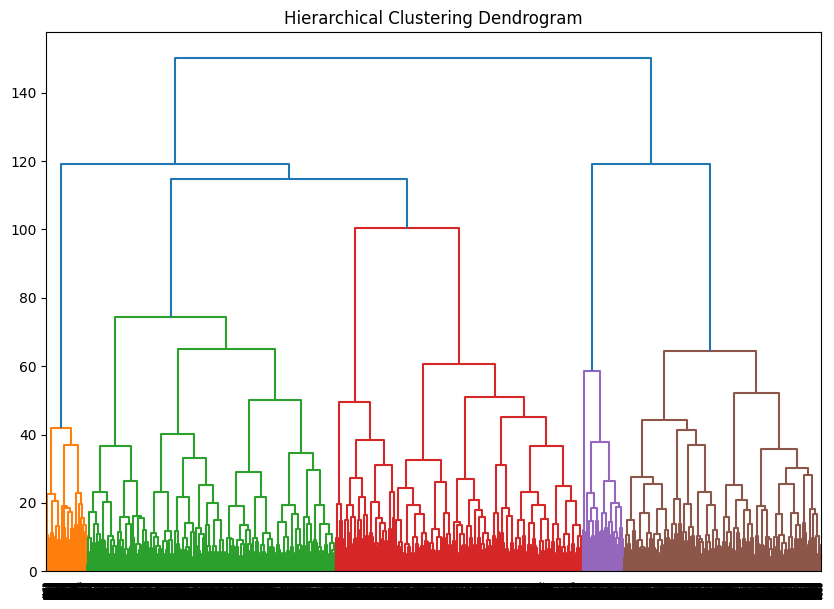

In [52]:
hier = AgglomerativeClustering(n_clusters=12, linkage='ward')
hier_labels = hier.fit_predict(X_sample_scaled)
sample_data['hier_cluster'] = hier_labels

print(sample_data['hier_cluster'].value_counts().sort_index())

hier_means = sample_data.groupby('hier_cluster')[audio_features].mean()
hier_means

from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X_sample_scaled, 'ward')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

# Reduce Dimensions with PCA and t-SNE for Cluster Visualization

Explained variance ratio: [0.18930082 0.13078454]


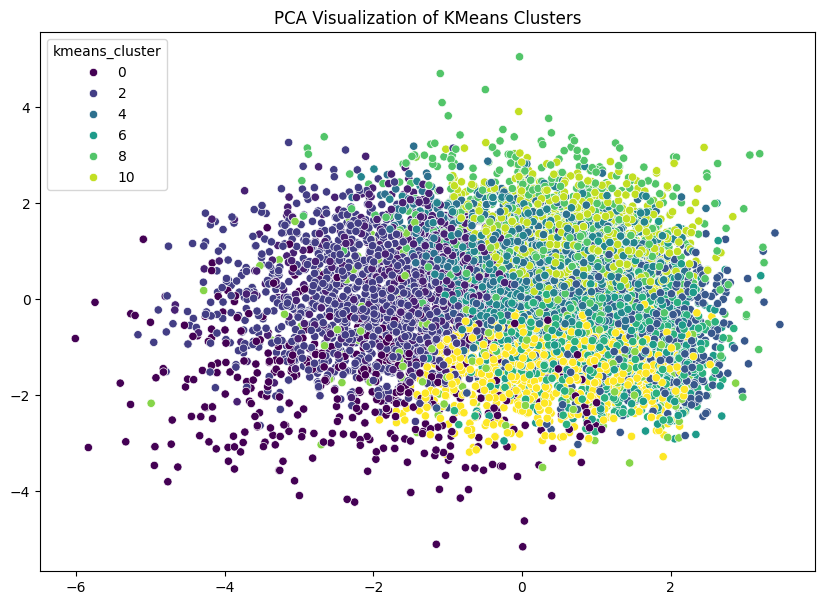

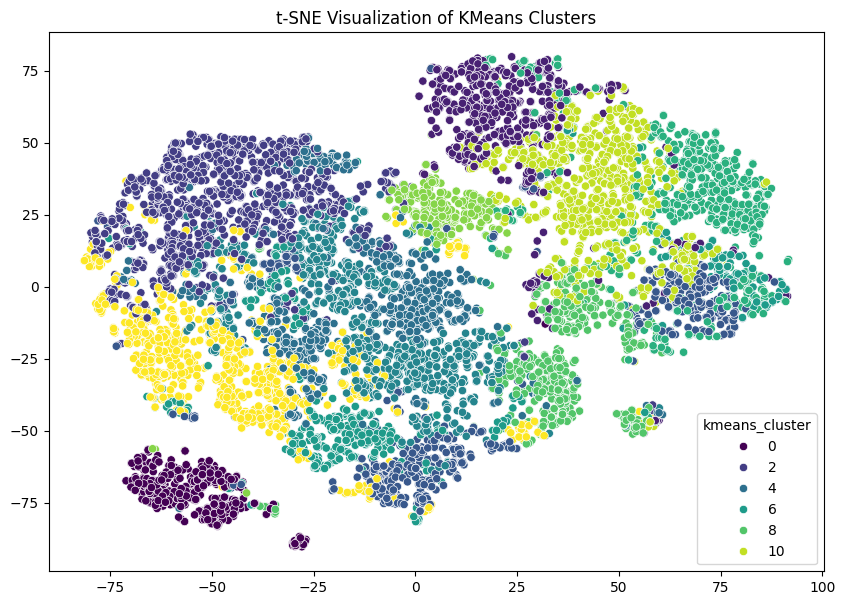

In [53]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample_scaled)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

sample_data['kmeans_cluster'] = kmeans.predict(X_sample_scaled)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=sample_data['kmeans_cluster'], palette='viridis')
plt.title('PCA Visualization of KMeans Clusters')
plt.show()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=sample_data['kmeans_cluster'], palette='viridis')
plt.title('t-SNE Visualization of KMeans Clusters')
plt.show()

# Validate Clusters with Musicological Characteristics

In [54]:
pd.crosstab(data['kmeans_cluster'], data['track_genre']).idxmax(axis=1)

for cluster in cluster_means.index:
    means = cluster_means.loc[cluster]
    description = f"Cluster {cluster}: "
    if means['energy'] > 0.7 and means['danceability'] > 0.6:
        description += "High energy and danceable - likely upbeat pop/EDM micro-genre."
    elif means['acousticness'] > 0.5 and means['energy'] < 0.4:
        description += "Acoustic and low energy - calm folk/acoustic micro-genre."
    elif means['instrumentalness'] > 0.5:
        description += "High instrumentalness - ambient/instrumental micro-genre."
    elif means['speechiness'] > 0.1:
        description += "High speechiness - rap/spoken word micro-genre."
    else:
        description += "Balanced features - general pop/rock micro-genre."
    print(description)


Cluster 0: Balanced features - general pop/rock micro-genre.
Cluster 1: Balanced features - general pop/rock micro-genre.
Cluster 2: Balanced features - general pop/rock micro-genre.
Cluster 3: Balanced features - general pop/rock micro-genre.
Cluster 4: High energy and danceable - likely upbeat pop/EDM micro-genre.
Cluster 5: High energy and danceable - likely upbeat pop/EDM micro-genre.
Cluster 6: High energy and danceable - likely upbeat pop/EDM micro-genre.
Cluster 7: Balanced features - general pop/rock micro-genre.
Cluster 8: High speechiness - rap/spoken word micro-genre.
Cluster 9: High energy and danceable - likely upbeat pop/EDM micro-genre.
Cluster 10: High energy and danceable - likely upbeat pop/EDM micro-genre.
Cluster 11: Balanced features - general pop/rock micro-genre.


# Deep Learing

# Cluster Embeddings

In [55]:
enc = OneHotEncoder(sparse_output=False)
cluster_embed = enc.fit_transform(data[['kmeans_cluster']])

data_clustered = pd.DataFrame(cluster_embed)


In [56]:
scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X)

# Build a DNN Regressor (5 hidden layers)


In [57]:
X_full = data.drop(columns=['popularity'])
y_full = data['popularity'] 
dnn_model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

dnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = dnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    sample_weight=w_train  
)

Epoch 1/30
611/611 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3046 - mae: 30.2145 - val_loss: 0.1597 - val_mae: 22.1464
Epoch 2/30
611/611 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1862 - mae: 25.5672 - val_loss: 0.1629 - val_mae: 21.8134
Epoch 3/30
611/611 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1651 - mae: 24.2233 - val_loss: 0.1602 - val_mae: 21.1237
Epoch 4/30
611/611 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1649 - mae: 24.1839 - val_loss: 0.1688 - val_mae: 21.2676
Epoch 5/30
611/611 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1616 - mae: 23.9070 - val_loss: 0.1996 - val_mae: 31.8535
Epoch 6/30
611/611 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1544 - mae: 23.5073 - val_loss: 0.1625 - val_mae: 25.1373
Epoch 7/30
611/611 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1570 - mae: 23.6867 - val_loss: 0.1775 - val_mae: 21.3950
Epoch 8/30
611/611 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1552 - mae: 23.4582 - val_loss: 0.1641 - val_mae: 25.8105
Epoch 9/30
611/611 ━━━━━━━━━━━━━━━━━━━━ 

 # Build an Autoencoder

In [58]:
input_dim = X_sample_scaled.shape[1]

input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)
bottleneck = layers.Dense(16, activation='relu')(encoded)

decoded = layers.Dense(32, activation='relu')(bottleneck)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)
encoder = models.Model(inputs=input_layer, outputs=bottleneck)

autoencoder.compile(optimizer='adam', loss='mse')

X_encoded=autoencoder.fit(
    X_sample_scaled, X_sample_scaled,
    epochs=25,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1381 - val_loss: 0.0159
Epoch 2/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0079 - val_loss: 0.0064
Epoch 3/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 4/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 5/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 6/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 8.2632e-04 - val_loss: 9.1387e-04
Epoch 7/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.0713e-04 - val_loss: 3.6987e-04
Epoch 8/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.2518e-04 - val_loss: 0.0015
Epoch 9/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.4997e-04 - val_loss: 1.3713e-04
Epoch 10/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.2393e-04 - val_loss: 0.0014
Epoch 11/25
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.0587e-04 - val_loss: 2.1475e-04
Epoch 12/25


In [59]:
X_encoded = encoder.predict(X_sample_scaled)


1908/1908 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step  


In [60]:
X_final = np.concatenate([X_sample_scaled, cluster_embed, X_encoded], axis=1)


In [61]:
class FeatureAttention(layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.w = layers.Dense(units)

    def call(self, x):
        scores = self.w(x)
        weights = tf.nn.softmax(scores, axis=1)
        x_weighted = x * weights
        return x_weighted, weights

inputs = Input(shape=(21,))
x_att, weights = FeatureAttention(21)(inputs)
x = layers.Dense(64, activation='relu')(x_att)
outputs = layers.Dense(1)(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse')


In [62]:
attention_layer = model.layers[1]
_, att_weights = attention_layer(X_train2)
feature_importance = tf.reduce_mean(att_weights, axis=0)
for v in feature_importance:
    print(f"{v*100:.6f} %")

0.025555 %
0.071049 %
0.000000 %
6.068265 %
0.000000 %
0.000000 %
0.000000 %
0.000000 %
0.000000 %
0.000058 %
0.000000 %
0.000000 %
0.000000 %
0.000355 %
0.000000 %
0.000000 %
0.144956 %
93.562897 %
0.000000 %
0.126896 %
0.000000 %


In [63]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))


Linear Regression MAE: 19.921133614792442


In [64]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

['random_forest_model.pkl']

In [68]:
joblib.dump(kmeans, 'kmeans_model.joblib')

['kmeans_model.joblib']

In [69]:
sample_data.to_csv('clustered_sample_data.csv', index=False)

In [70]:
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [71]:
pd.read_csv('clustered_sample_data.csv')

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,...,track_genre,energy_dance_ratio,acoustic_electronic_spectrum,tempo_duration_ratio,mood_score,duration_log,pop_bin,dbscan_cluster,hier_cluster,kmeans_cluster
0,ヴィヴィ(Vo.八木海莉),Sing My Pleasure,Sing My Pleasure,55,False,0.477,0.954,5,-2.400,0,...,anime,1.999996,0.003885,0.302253,0.7045,12.575133,5,-1,0,3
1,Ryuji Imaichi,RILY,RILY,21,False,0.716,0.755,1,-4.344,1,...,j-dance,1.054468,0.116071,0.520869,0.6720,12.102749,2,-1,1,4
2,Carajo,Inmundo,Una Oportunidad,23,False,0.647,0.939,10,-2.873,0,...,heavy-metal,1.451312,0.000924,0.542740,0.8405,12.355126,2,-1,0,10
3,Mr.Children,深海,Mirror,39,False,0.647,0.527,0,-8.454,1,...,j-rock,0.814527,0.302083,0.618901,0.5930,12.093654,3,-1,1,4
4,Gregory Isaacs,One Man Against The World,Night Nurse,25,False,0.832,0.383,7,-12.103,1,...,dub,0.460336,0.020512,0.311716,0.6425,12.385227,2,-1,8,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Jason Mraz,YES!,Long Drive,43,False,0.527,0.578,7,-8.650,1,...,acoustic,1.096772,0.245330,0.641979,0.4915,12.349077,4,-1,3,11
9996,Alka Yagnik;Arijit Singh,Loveholic Arijit Singh,"Agar Tum Saath Ho (From ""Tamasha"")",52,False,0.562,0.519,3,-8.744,1,...,k-pop,0.923486,1.257334,0.360427,0.4670,12.739799,5,-1,5,2
9997,Michael Ball;Imelda Staunton,Sweeney Todd (The 2012 London Cast Recording),Epiphany,21,False,0.469,0.728,7,-8.149,1,...,opera,1.552235,0.964635,0.511498,0.5855,12.289007,2,-1,3,3
9998,Rod Stewart;Michael Bublé,Santa Claus Is Coming To Town,Winter Wonderland,0,False,0.684,0.491,0,-7.655,1,...,rock,0.717835,2.448267,0.823286,0.4455,11.872186,0,-1,5,2


In [79]:
print(data['track_genre'].unique())

['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-pop'
 'progressive-house' 'psych-rock' 'punk-rock' 'punk' 'r-n-b' 'reggae'
 'reggaeton' 'rock-n-roll' 'rock' 'rockabilly' 'romance' 'sad' 'salsa'
 'samba' 'sertanejo' 'show